# Results: Mixed gridsearch

Accuracy heatmaps for `gs_single_mixed` and `gs_binary_mixed`,
swept over $p_{hd}$ and $d = k/N$ for each expansion config and learning rate $p$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle

In [2]:
# Load gridsearch results
with open('data/gs_single_mixed.pkl', 'rb') as f:
    gs_single = pickle.load(f)

with open('data/gs_binary_mixed.pkl', 'rb') as f:
    gs_binary = pickle.load(f)

print('Single keys:', list(gs_single.keys()))
print('Binary keys:', list(gs_binary.keys()))

Single keys: ['params', 'results', 'pair_log', 'config_specs']
Binary keys: ['params', 'results', 'pair_log', 'config_specs']


In [3]:
def build_acc_table(gs, p_val=None):
    """Aggregate gridsearch results into (config, p_hd, d) -> (mean, std) acc table.
    
    If p_val is given, filter to that learning rate first.
    """
    params = gs['params']
    results = gs['results']

    expansion = np.asarray(params['expansion'])
    p_hd = np.asarray(params['p_hd'], dtype=float)
    d = np.asarray(params['d'], dtype=float)
    acc = np.asarray(results['test_acc'], dtype=float)

    if p_val is not None:
        p = np.asarray(params['p'], dtype=float)
        mask = np.isclose(p, p_val)
        expansion, p_hd, d, acc = expansion[mask], p_hd[mask], d[mask], acc[mask]

    config_names = list(dict.fromkeys(expansion))  # preserve order
    p_hd_sweep = sorted(set(p_hd))
    d_sweep = sorted(set(d))

    acc_table = {}
    for cfg in config_names:
        for ph in p_hd_sweep:
            for dv in d_sweep:
                m = (expansion == cfg) & np.isclose(p_hd, ph) & np.isclose(d, dv)
                accs = acc[m]
                if len(accs) > 0:
                    acc_table[(cfg, ph, dv)] = (np.mean(accs), np.std(accs))

    return config_names, p_hd_sweep, d_sweep, acc_table

In [4]:
def plot_heatmaps(config_names, p_hd_sweep, d_sweep, acc_table, title):
    """Accuracy heatmaps: one per expansion config."""
    fig, axes = plt.subplots(1, len(config_names),
                             figsize=(3.5 * len(config_names), 4),
                             constrained_layout=True)
    if len(config_names) == 1:
        axes = [axes]

    # Global colorbar limits
    all_means = [acc_table[(c, p, d)][0]
                 for c in config_names for p in p_hd_sweep for d in d_sweep
                 if (c, p, d) in acc_table]
    vmin, vmax = min(all_means), max(all_means)

    for ci, cfg_name in enumerate(config_names):
        ax = axes[ci]

        mat = np.zeros((len(d_sweep), len(p_hd_sweep)))
        annot = np.empty_like(mat, dtype=object)
        for i, d in enumerate(d_sweep):
            for j, p in enumerate(p_hd_sweep):
                if (cfg_name, p, d) in acc_table:
                    m, s = acc_table[(cfg_name, p, d)]
                else:
                    m, s = 0, 0
                mat[i, j] = m
                annot[i, j] = f'{m:.2f}'

        im = ax.imshow(mat, aspect='auto', vmin=vmin, vmax=vmax, cmap='viridis',
                       origin='upper')

        for i in range(len(d_sweep)):
            for j in range(len(p_hd_sweep)):
                color = 'white' if mat[i, j] < (vmin + vmax) / 2 else 'black'
                ax.text(j, i, annot[i, j], ha='center', va='center',
                        fontsize=8, color=color)

        ax.set_xticks(range(len(p_hd_sweep)))
        ax.set_xticklabels([f'{p}' for p in p_hd_sweep], fontsize=9, rotation=45)
        ax.set_xlabel('$p_{hd}$')

        ax.set_yticks(range(len(d_sweep)))
        ax.set_yticklabels([f'{d}' for d in d_sweep], fontsize=9)
        if ci == 0:
            ax.set_ylabel('$d = k/N$')

        ax.set_title(cfg_name, fontsize=10)

    fig.colorbar(im, ax=axes, label='Classification accuracy', shrink=0.8)
    fig.suptitle(title, fontsize=13, fontweight='bold')
    plt.show()

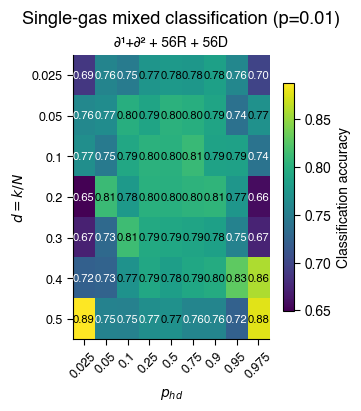

In [5]:
# Single-gas mixed, p=0.01
cfg, phd, d, acc = build_acc_table(gs_single, p_val=0.01)
plot_heatmaps(cfg, phd, d, acc, 'Single-gas mixed classification (p=0.01)')

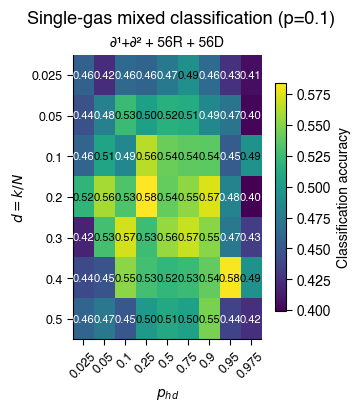

In [6]:
# Single-gas mixed, p=0.1
cfg, phd, d, acc = build_acc_table(gs_single, p_val=0.1)
plot_heatmaps(cfg, phd, d, acc, 'Single-gas mixed classification (p=0.1)')

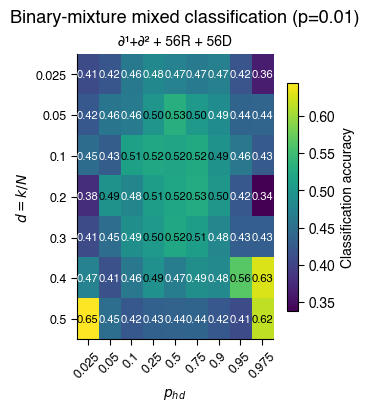

In [7]:
# Binary-mixture mixed, p=0.01
cfg, phd, d, acc = build_acc_table(gs_binary, p_val=0.01)
plot_heatmaps(cfg, phd, d, acc, 'Binary-mixture mixed classification (p=0.01)')

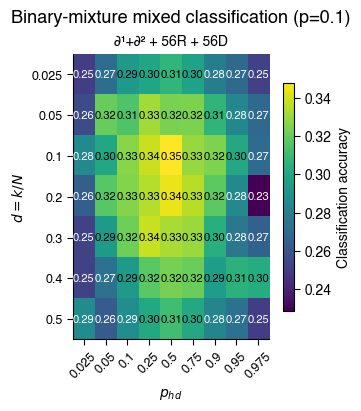

In [8]:
# Binary-mixture mixed, p=0.1
cfg, phd, d, acc = build_acc_table(gs_binary, p_val=0.1)
plot_heatmaps(cfg, phd, d, acc, 'Binary-mixture mixed classification (p=0.1)')